# ⚠️ NO_PRIOR_KEEP_TEAM ABLATION VARIANT (Year-to-Year)

Year-to-year temporal validation with **shooter-identity features removed but `teamTricode` KEPT**.

**Why this variant:** The NO_PRIOR variant conflated shooter-identity removal with removing the team fixed effect. This variant fixes that — drops only the six `prior_*` features, keeps `teamTricode` so team-level effects aren't collapsed toward the league mean.

**Removed (6):** `prior_fg_pct`, `prior_fg3_pct`, `prior_fg2_pct`, `prior_shot_type_pct`, `prior_attempts`, `prior_high_volume`

**Kept:** `teamTricode`, `opp_def_*` (opponent defense), shot context, shot mechanics.

Output: `year_to_year_temporal_validation_results_no_prior_keep_team.csv` (main and NO_PRIOR results NOT overwritten).

See `NO_PRIOR_ABLATION_REVIEW.md` for full ablation context.

---

# Year-to-Year Temporal Validation: 2020-2025

This notebook performs year-to-year temporal validation to test model generalization across consecutive seasons:

- **2020 -> 2021**: Train on 2019-20 only, test on 2020-21
- **2021 -> 2022**: Train on 2020-21 only, test on 2021-22
- **2022 -> 2023**: Train on 2021-22 only, test on 2022-23
- **2023 -> 2024**: Train on 2022-23 only, test on 2023-24
- **2024 -> 2025**: Train on 2023-24 only, test on 2024-25

## Setup

### Model
- **Primary Model**: LightGBM (Model B: ~66.2% mean AUC across folds; Model A was ~67.1%)
- **Hyperparameters**: Pre-tuned from Bayesian optimization in the main notebook (Model A's tuning; reused here for A/B comparability)

### Features (NO_PRIOR variant)
- **Base**: `shotDistance`, `SHOT_CLOCK_APPROX`, coordinates, `period`, `contest_score`
- **Shot clock × location interactions**: 13 features
- **Text-parsed**: pullup, stepback, fadeaway, driving, floating, etc.
- **Court zone**: `is_paint`, `is_corner3`, `is_above_break3`, `is_midrange`
- **Opponent defense**: `opp_def_fg_pct`, `opp_def_rim_pct`, `opp_def_3pt_pct`, `opp_def_mid_pct`, `opp_def_shot_type_pct`
- **~~Prior season shooter stats~~**: **REMOVED** (`prior_fg_pct`, `prior_fg3_pct`, `prior_fg2_pct`, `prior_shot_type_pct`, `prior_attempts`, `prior_high_volume`)
- **~~teamTricode~~**: **REMOVED** as categorical (still present in df for grouping)

### Configuration
- `RANDOM_STATE = 42`
- Year-to-year folds: Train on single year → Test on next year
- Prior stats CSV still loaded (shooter columns just get ignored downstream)

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, accuracy_score
import matplotlib.pyplot as plt

# Optional imports
try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not available. Install: pip install lightgbm")

# Configuration
RANDOM_STATE = 42

# Best LightGBM hyperparameters from main notebook (Bayesian optimization)
BEST_LGBM_PARAMS = {
    'n_estimators': 563,
    'max_depth': 8,
    'learning_rate': 0.0117,
    'num_leaves': 84,
    'subsample': 0.668,
    'colsample_bytree': 0.626,
    'reg_alpha': 3.47,
    'reg_lambda': 4.91,
    'min_child_samples': 42,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1
}

# Fallback HistGradientBoosting params
BEST_HISTGB_PARAMS = {
    'max_iter': 282,
    'max_depth': 10,
    'learning_rate': 0.0197,
    'max_leaf_nodes': 74,
    'min_samples_leaf': 32,
    'random_state': RANDOM_STATE
}

# ============================================================================
# LEAKAGE COLUMNS - Must be excluded!
# ============================================================================
LEAKAGE_COLUMNS = ['scoreHome', 'scoreAway', 'pointsTotal', 'shotResult', 'target']

# ============================================================================
# Load Historical Stats Files
# ============================================================================
PLAYER_STATS_PATH = 'player_historical_stats.csv'
TEAM_DEF_STATS_PATH = 'team_defensive_stats.csv'

player_hist = None
team_def_hist = None

if os.path.exists(PLAYER_STATS_PATH):
    player_hist = pd.read_csv(PLAYER_STATS_PATH)
    print(f"Loaded player historical stats: {len(player_hist):,} records, seasons {player_hist['season_year'].min()}-{player_hist['season_year'].max()}")
else:
    print(f"Warning: {PLAYER_STATS_PATH} not found - prior player features disabled")

if os.path.exists(TEAM_DEF_STATS_PATH):
    team_def_hist = pd.read_csv(TEAM_DEF_STATS_PATH)
    print(f"Loaded team defensive stats: {len(team_def_hist):,} records, seasons {team_def_hist['season_year'].min()}-{team_def_hist['season_year'].max()}")
else:
    print(f"Warning: {TEAM_DEF_STATS_PATH} not found - opponent defense features disabled")

# ============================================================================
# Function to merge prior season stats
# ============================================================================
def merge_prior_stats(df, prior_season_year):
    """Merge prior season player and team defensive stats into shot data."""
    df = df.copy()
    
    # --- Player Prior Stats ---
    if player_hist is not None and 'personId' in df.columns:
        prior_stats = player_hist[player_hist['season_year'] == prior_season_year][
            ['personId', 'fg_pct', 'fg3_pct', 'fg2_pct', 'total_attempts']
        ].copy()
        prior_stats.columns = ['personId', 'prior_fg_pct', 'prior_fg3_pct', 'prior_fg2_pct', 'prior_attempts']
        
        df = df.merge(prior_stats, on='personId', how='left')
        
        # Fill missing with league averages
        league_avg_fg = prior_stats['prior_fg_pct'].mean() if len(prior_stats) > 0 else 0.45
        league_avg_fg3 = prior_stats['prior_fg3_pct'].mean() if len(prior_stats) > 0 else 0.35
        league_avg_fg2 = prior_stats['prior_fg2_pct'].mean() if len(prior_stats) > 0 else 0.50
        league_avg_attempts = prior_stats['prior_attempts'].median() if len(prior_stats) > 0 else 200
        
        df['prior_fg_pct'] = df['prior_fg_pct'].fillna(league_avg_fg)
        df['prior_fg3_pct'] = df['prior_fg3_pct'].fillna(league_avg_fg3)
        df['prior_fg2_pct'] = df['prior_fg2_pct'].fillna(league_avg_fg2)
        df['prior_attempts'] = df['prior_attempts'].fillna(league_avg_attempts)
        
        # Shot-type-specific prior percentage
        df['prior_shot_type_pct'] = np.where(
            df['shotValue'] == 3,
            df['prior_fg3_pct'],
            df['prior_fg2_pct']
        )
        
        # High volume indicator
        df['prior_high_volume'] = (df['prior_attempts'] >= 300).astype(int)
    
    # --- Opponent Defensive Stats ---
    if team_def_hist is not None and 'teamId' in df.columns and 'gameId' in df.columns:
        # Get unique (gameId, teamId) pairs
        game_teams = df[['gameId', 'teamId']].drop_duplicates()
        
        # Self-join to find opponent
        game_teams_opp = game_teams.merge(game_teams, on='gameId', suffixes=('', '_opp'))
        game_teams_opp = game_teams_opp[game_teams_opp['teamId'] != game_teams_opp['teamId_opp']]
        game_teams_opp = game_teams_opp.rename(columns={'teamId_opp': 'opponentId'})
        
        # Merge opponent ID into shots
        df = df.merge(game_teams_opp[['gameId', 'teamId', 'opponentId']], on=['gameId', 'teamId'], how='left')
        
        # Get prior season defensive stats
        prior_def = team_def_hist[team_def_hist['season_year'] == prior_season_year][
            ['teamId', 'opp_fg_pct_allowed', 'opp_rim_fg_pct_allowed', 
             'opp_3pt_pct_allowed', 'opp_mid_fg_pct_allowed']
        ].copy()
        prior_def.columns = ['opponentId', 'opp_def_fg_pct', 'opp_def_rim_pct', 
                             'opp_def_3pt_pct', 'opp_def_mid_pct']
        
        df = df.merge(prior_def, on='opponentId', how='left')
        
        # Fill missing with league average
        for col in ['opp_def_fg_pct', 'opp_def_rim_pct', 'opp_def_3pt_pct', 'opp_def_mid_pct']:
            avg_val = prior_def[col].mean() if len(prior_def) > 0 else 0.46
            df[col] = df[col].fillna(avg_val)
        
        # Shot-type-specific opponent defense
        df['opp_def_shot_type_pct'] = np.where(
            df['shotValue'] == 3,
            df['opp_def_3pt_pct'],
            np.where(df['shotDistance'] <= 5, df['opp_def_rim_pct'], df['opp_def_mid_pct'])
        )
    
    return df

# ============================================================================
# Feature Engineering Function (matches main notebook)
# ============================================================================
def engineer_features(df):
    df = df.copy()
    
    # Base columns
    dist = pd.to_numeric(df.get('shotDistance', 0), errors='coerce').fillna(0)
    sc = pd.to_numeric(df.get('SHOT_CLOCK_APPROX', 12), errors='coerce').fillna(12)
    x_raw = pd.to_numeric(df.get('xLegacy', 0), errors='coerce').fillna(0)
    y_raw = pd.to_numeric(df.get('yLegacy', 0), errors='coerce').fillna(0)
    shot_value = pd.to_numeric(df.get('shotValue', 2), errors='coerce').fillna(2)
    
    # Distance features
    df['shot_distance_log'] = np.log1p(dist)
    df['shot_distance_sq'] = dist ** 2
    df['is_paint'] = (dist <= 8).astype(int)
    df['is_midrange'] = ((dist > 8) & (dist <= 22)).astype(int)
    
    # Court coordinates
    x_ft = x_raw / 10.0
    y_ft = y_raw / 10.0
    df['shot_angle_rad'] = np.arctan2(y_ft, np.abs(x_ft))
    df['is_corner3'] = ((shot_value == 3) & (x_ft.abs() >= 22.0) & (y_ft <= 5.0)).astype(int)
    df['is_above_break3'] = ((shot_value == 3) & (df['is_corner3'] == 0)).astype(int)
    
    # Shot clock features
    df['is_late_clock'] = (sc <= 5).astype(int)
    df['is_early_clock'] = (sc >= 18).astype(int)
    df['is_heave'] = (sc <= 2).astype(int)
    
    # Shot clock buckets
    df['clock_0_4'] = ((sc >= 0) & (sc < 4)).astype(int)
    df['clock_4_8'] = ((sc >= 4) & (sc < 8)).astype(int)
    df['clock_8_12'] = ((sc >= 8) & (sc < 12)).astype(int)
    df['clock_12_16'] = ((sc >= 12) & (sc < 16)).astype(int)
    df['clock_16_20'] = ((sc >= 16) & (sc < 20)).astype(int)
    df['clock_20_24'] = ((sc >= 20) & (sc <= 24)).astype(int)
    
    # Shot Clock x Location Interactions
    df['clock_x_distance'] = sc * dist
    df['is_transition_paint'] = ((sc >= 18) & (dist <= 8)).astype(int)
    df['is_transition_midrange'] = ((sc >= 18) & (dist > 8) & (dist <= 22)).astype(int)
    df['is_transition_3pt'] = ((sc >= 18) & (shot_value == 3)).astype(int)
    df['is_late_clock_paint'] = ((sc <= 5) & (dist <= 8)).astype(int)
    df['is_late_clock_midrange'] = ((sc <= 5) & (dist > 8) & (dist <= 22)).astype(int)
    df['is_desperation_3pt'] = ((sc <= 5) & (shot_value == 3)).astype(int)
    df['is_heave_shot'] = ((sc <= 2) & (dist >= 28)).astype(int)
    df['clock_x_paint'] = sc * df['is_paint']
    df['clock_x_corner3'] = sc * df['is_corner3']
    df['clock_x_above_break3'] = sc * df['is_above_break3']
    df['is_rhythm_shot'] = ((sc >= 8) & (sc <= 16)).astype(int)
    df['rhythm_x_distance'] = df['is_rhythm_shot'] * dist
    
    # Text-parsed features
    action = df.get('actionType', pd.Series([''] * len(df))).fillna('').str.lower()
    subtype = df.get('subType', pd.Series([''] * len(df))).fillna('').str.lower()
    desc = df.get('description', pd.Series([''] * len(df))).fillna('').str.lower()
    combined = action + ' ' + subtype + ' ' + desc
    
    df['is_pullup'] = combined.str.contains('pullup|pull-up|pull up', regex=True).astype(int)
    df['is_stepback'] = combined.str.contains('step back|stepback', regex=True).astype(int)
    df['is_fadeaway'] = combined.str.contains('fadeaway|fade away', regex=True).astype(int)
    df['is_turnaround'] = (combined.str.contains('turnaround') & ~combined.str.contains('fadeaway')).astype(int)
    df['is_driving'] = combined.str.contains('driving').astype(int)
    df['is_floating'] = combined.str.contains('floating|floater|runner', regex=True).astype(int)
    df['is_cutting'] = combined.str.contains('cutting|cut', regex=True).astype(int)
    df['is_tip'] = combined.str.contains('tip').astype(int)
    df['is_putback'] = combined.str.contains('putback|put-back|put back', regex=True).astype(int)
    df['is_second_chance'] = (df['is_putback'] | df['is_tip']).astype(int)
    
    return df

# ============================================================================
# Feature Lists (matching main notebook)
# ============================================================================
NUMERIC_FEATURES = [
    'shotDistance', 'SHOT_CLOCK_APPROX', 'xLegacy', 'yLegacy', 'period',
    'contest_score', 'shotValue', 'ABS_TIME',
    'shot_distance_log', 'shot_distance_sq', 'shot_angle_rad',
    'clock_x_distance', 'clock_x_paint', 'clock_x_corner3', 'clock_x_above_break3',
    'rhythm_x_distance',
]

# NO_PRIOR ablation: shooter-identity features dropped, opponent defense kept
PRIOR_FEATURES = [
    # === ABLATED: shooter-prior stats removed ===
    # 'prior_fg_pct', 'prior_fg3_pct', 'prior_fg2_pct', 'prior_shot_type_pct',
    # 'prior_attempts', 'prior_high_volume',
    'opp_def_fg_pct', 'opp_def_rim_pct', 'opp_def_3pt_pct', 'opp_def_mid_pct',
    'opp_def_shot_type_pct',
]

BINARY_FEATURES = [
    'is_paint', 'is_midrange', 'is_corner3', 'is_above_break3',
    'is_late_clock', 'is_early_clock', 'is_heave',
    'clock_0_4', 'clock_4_8', 'clock_8_12', 'clock_12_16', 'clock_16_20', 'clock_20_24',
    'is_transition_paint', 'is_transition_midrange', 'is_transition_3pt',
    'is_late_clock_paint', 'is_late_clock_midrange', 'is_desperation_3pt',
    'is_heave_shot', 'is_rhythm_shot',
    'is_pullup', 'is_stepback', 'is_fadeaway', 'is_turnaround',
    'is_driving', 'is_floating', 'is_cutting', 'is_tip', 'is_putback', 'is_second_chance',
]

CATEGORICAL_FEATURES = [
    # teamTricode KEPT (NO_PRIOR_KEEP_TEAM): team fixed effect, not shooter identity
    'subType', 'contest_label', 'teamTricode', 'location'
]

print(f"\nLightGBM available: {LIGHTGBM_AVAILABLE}")
print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(f"Prior features: {len(PRIOR_FEATURES)}")
print(f"Binary features: {len(BINARY_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Total: {len(NUMERIC_FEATURES) + len(PRIOR_FEATURES) + len(BINARY_FEATURES) + len(CATEGORICAL_FEATURES)}")

## 2. Load All Seasons

In [2]:
# Define season mappings
seasons = {
    2020: 'enriched_data/nbastatsv3_2019_enriched_shots.csv',  # 2019-20 season
    2021: 'enriched_data/nbastatsv3_2020_enriched_shots.csv',  # 2020-21 season
    2022: 'enriched_data/nbastatsv3_2021_enriched_shots.csv',  # 2021-22 season
    2023: 'enriched_data/nbastatsv3_2022_enriched_shots.csv',  # 2022-23 season
    2024: 'enriched_data/nbastatsv3_2023_enriched_shots.csv',  # 2023-24 season
    2025: 'enriched_data/nbastatsv3_2024_enriched_shots.csv',  # 2024-25 season
}

# Load all seasons and apply feature engineering
data = {}
for year, path in seasons.items():
    try:
        df = pd.read_csv(path)
        # Create binary target
        df['target'] = (df['shotResult'].astype(str).str.strip().str.lower() == 'made').astype(int)
        # Apply feature engineering
        df = engineer_features(df)
        data[year] = df
        print(f"Loaded {year}: {len(df):,} shots, FG% = {df['target'].mean():.1%}")
    except FileNotFoundError:
        print(f"Warning: {year}: File not found at {path}")

print(f"\nLoaded {len(data)} seasons")

Loaded 2020: 188,116 shots, FG% = 46.0%
Loaded 2021: 190,983 shots, FG% = 46.6%
Loaded 2022: 216,722 shots, FG% = 46.1%
Loaded 2023: 217,219 shots, FG% = 47.5%
Loaded 2024: 218,702 shots, FG% = 47.4%
Loaded 2025: 219,528 shots, FG% = 46.7%

Loaded 6 seasons


## 3. Define Features & Preprocessing

In [3]:
# Feature summary
print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(f"Opp defense features (was PRIOR_FEATURES, shooter-prior ablated): {len(PRIOR_FEATURES)}")
print(f"Binary features: {len(BINARY_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Total features: {len(NUMERIC_FEATURES) + len(PRIOR_FEATURES) + len(BINARY_FEATURES) + len(CATEGORICAL_FEATURES)}")
print(f"\nLeakage columns excluded: {LEAKAGE_COLUMNS}")

# Preprocessing pipeline (dense for tree-based models)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

Numeric features: 16
Prior features: 5
Binary features: 31
Categorical features: 3
Total features: 55

Leakage columns excluded: ['scoreHome', 'scoreAway', 'pointsTotal', 'shotResult', 'target']


## 4. Year-to-Year Temporal Validation

In [4]:
# Define year-to-year validation folds (train on single year, test on next year)
folds = [
    {'train_year': 2020, 'test_year': 2021, 'name': '2020 -> 2021'},
    {'train_year': 2021, 'test_year': 2022, 'name': '2021 -> 2022'},
    {'train_year': 2022, 'test_year': 2023, 'name': '2022 -> 2023'},
    {'train_year': 2023, 'test_year': 2024, 'name': '2023 -> 2024'},
    {'train_year': 2024, 'test_year': 2025, 'name': '2024 -> 2025'},
]

results = []

print("="*80)
print("YEAR-TO-YEAR TEMPORAL VALIDATION (LightGBM with Optimized Features)")
print("="*80)

for fold in folds:
    train_year = fold['train_year']
    test_year = fold['test_year']
    fold_name = fold['name']
    
    print(f"\n{'='*80}")
    print(f"FOLD: {fold_name}")
    print(f"{'='*80}")
    
    # Check if required seasons are available
    if train_year not in data:
        print(f"Warning: Skipping - Training year {train_year} not available")
        continue
    if test_year not in data:
        print(f"Warning: Skipping - Test year {test_year} not available")
        continue
    
    # Get single year training data and test data
    train_df = data[train_year].copy()
    test_df = data[test_year].copy()
    
    # Apply prior season stats (using prior year's data - no leakage)
    # For train_year 2020, use prior stats from 2019
    # For test_year 2021, use prior stats from 2020
    prior_year_for_train = train_year - 1
    prior_year_for_test = test_year - 1
    
    print(f"\nMerging prior stats...")
    print(f"  Training data ({train_year}): using prior stats from {prior_year_for_train}")
    print(f"  Test data ({test_year}): using prior stats from {prior_year_for_test}")
    
    train_df = merge_prior_stats(train_df, prior_year_for_train)
    test_df = merge_prior_stats(test_df, prior_year_for_test)
    
    # Filter features to those available (excluding leakage columns)
    num_features = [f for f in NUMERIC_FEATURES + PRIOR_FEATURES + BINARY_FEATURES 
                    if f in train_df.columns and f not in LEAKAGE_COLUMNS]
    cat_features = [f for f in CATEGORICAL_FEATURES 
                    if f in train_df.columns and f not in LEAKAGE_COLUMNS]
    all_features = num_features + cat_features
    
    # Count prior features available
    prior_in_train = [f for f in PRIOR_FEATURES if f in train_df.columns]
    
    print(f"\nTraining on: {train_year} only ({len(train_df):,} shots)")
    print(f"Testing on: {test_year} ({len(test_df):,} shots)")
    print(f"Features: {len(num_features)} numeric (incl. {len(prior_in_train)} opp_def) + {len(cat_features)} categorical")
    
    # Build preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_features),
            ('cat', categorical_transformer, cat_features)
        ],
        remainder='drop'
    )
    
    X_train = train_df[all_features]
    y_train = train_df['target']
    X_test = test_df[all_features]
    y_test = test_df['target']
    
    # Select model (LightGBM > HistGradientBoosting)
    if LIGHTGBM_AVAILABLE:
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', LGBMClassifier(**BEST_LGBM_PARAMS))
        ])
        model_name = 'LightGBM'
    else:
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', HistGradientBoostingClassifier(**BEST_HISTGB_PARAMS))
        ])
        model_name = 'HistGradientBoosting'
    
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)
    
    # Predict on test set
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Calculate metrics
    auc = roc_auc_score(y_test, y_pred_proba)
    logloss = log_loss(y_test, y_pred_proba, labels=[0, 1])
    brier = brier_score_loss(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    
    # Find best threshold
    best_thresh, best_acc = 0.5, acc
    for t in np.arange(0.4, 0.6, 0.01):
        a = accuracy_score(y_test, (y_pred_proba >= t).astype(int))
        if a > best_acc:
            best_acc, best_thresh = a, t
    
    print(f"\n{model_name} Results:")
    print(f"  AUC:       {auc:.4f}")
    print(f"  Log Loss:  {logloss:.4f}")
    print(f"  Brier:     {brier:.4f}")
    print(f"  Accuracy:  {best_acc*100:.2f}% (threshold={best_thresh:.2f})")
    
    # Store results
    results.append({
        'fold': fold_name,
        'train_year': train_year,
        'test_year': test_year,
        'model': model_name,
        'n_train': len(X_train),
        'n_test': len(X_test),
        'n_features': len(all_features),
        'auc': auc,
        'log_loss': logloss,
        'brier': brier,
        'accuracy': best_acc,
        'threshold': best_thresh,
        'train_fg_pct': y_train.mean(),
        'test_fg_pct': y_test.mean(),
    })

print("\n" + "="*80)
print("YEAR-TO-YEAR VALIDATION COMPLETE")
print("="*80)

YEAR-TO-YEAR TEMPORAL VALIDATION (LightGBM with Optimized Features)

FOLD: 2020 -> 2021

Merging prior stats...
  Training data (2020): using prior stats from 2019
  Test data (2021): using prior stats from 2020

Training on: 2020 only (188,116 shots)
Testing on: 2021 (190,983 shots)
Features: 52 numeric (incl. 5 prior) + 3 categorical

Training LightGBM...

LightGBM Results:
  AUC:       0.6560
  Log Loss:  0.6391
  Brier:     0.2252
  Accuracy:  62.89% (threshold=0.49)

FOLD: 2021 -> 2022

Merging prior stats...
  Training data (2021): using prior stats from 2020
  Test data (2022): using prior stats from 2021

Training on: 2021 only (190,983 shots)
Testing on: 2022 (216,722 shots)
Features: 52 numeric (incl. 5 prior) + 3 categorical

Training LightGBM...

LightGBM Results:
  AUC:       0.6631
  Log Loss:  0.6341
  Brier:     0.2228
  Accuracy:  63.64% (threshold=0.50)

FOLD: 2022 -> 2023

Merging prior stats...
  Training data (2022): using prior stats from 2021
  Test data (2023): 

## 5. Summary Results Table

In [5]:
# Create results dataframe
results_df = pd.DataFrame(results)

# Display full table
print("\n" + "="*80)
print("YEAR-TO-YEAR TEMPORAL VALIDATION SUMMARY")
print("="*80)
print()

# Format for display (use correct column names)
display_df = results_df[[
    'fold',
    'n_train',
    'n_test',
    'n_features',
    'auc',
    'log_loss',
    'brier',
    'accuracy'
]].copy()

display_df.columns = ['Fold', 'Train N', 'Test N', 'Features', 'AUC', 'Log Loss', 'Brier', 'Accuracy']

print(display_df.to_string(index=False))
print()

# Calculate average metrics
print("\n" + "-"*80)
print("AVERAGE METRICS ACROSS ALL FOLDS:")
print("-"*80)
print(f"  Mean AUC:      {results_df['auc'].mean():.4f} +/- {results_df['auc'].std():.4f}")
print(f"  Mean Log Loss: {results_df['log_loss'].mean():.4f} +/- {results_df['log_loss'].std():.4f}")
print(f"  Mean Brier:    {results_df['brier'].mean():.4f} +/- {results_df['brier'].std():.4f}")
print(f"  Mean Accuracy: {results_df['accuracy'].mean():.4f} +/- {results_df['accuracy'].std():.4f}")
print(f"                 ({results_df['accuracy'].mean()*100:.2f}% +/- {results_df['accuracy'].std()*100:.2f}%)")
print(f"  Avg Features:  {results_df['n_features'].mean():.0f}")
print("-"*80)


YEAR-TO-YEAR TEMPORAL VALIDATION SUMMARY

        Fold  Train N  Test N  Features      AUC  Log Loss    Brier  Accuracy
2020 -> 2021   188116  190983        55 0.655975  0.639131 0.225169  0.628904
2021 -> 2022   190983  216722        55 0.663149  0.634117 0.222757  0.636437
2022 -> 2023   216722  217219        55 0.667191  0.634281 0.223011  0.632597
2023 -> 2024   217219  218702        55 0.663853  0.635592 0.223613  0.630954
2024 -> 2025   218702  219528        55 0.661397  0.635873 0.223640  0.632115


--------------------------------------------------------------------------------
AVERAGE METRICS ACROSS ALL FOLDS:
--------------------------------------------------------------------------------
  Mean AUC:      0.6623 +/- 0.0041
  Mean Log Loss: 0.6358 +/- 0.0020
  Mean Brier:    0.2236 +/- 0.0009
  Mean Accuracy: 0.6322 +/- 0.0028
                 (63.22% +/- 0.28%)
  Avg Features:  55
--------------------------------------------------------------------------------


## 6. Visualization: Performance Over Time

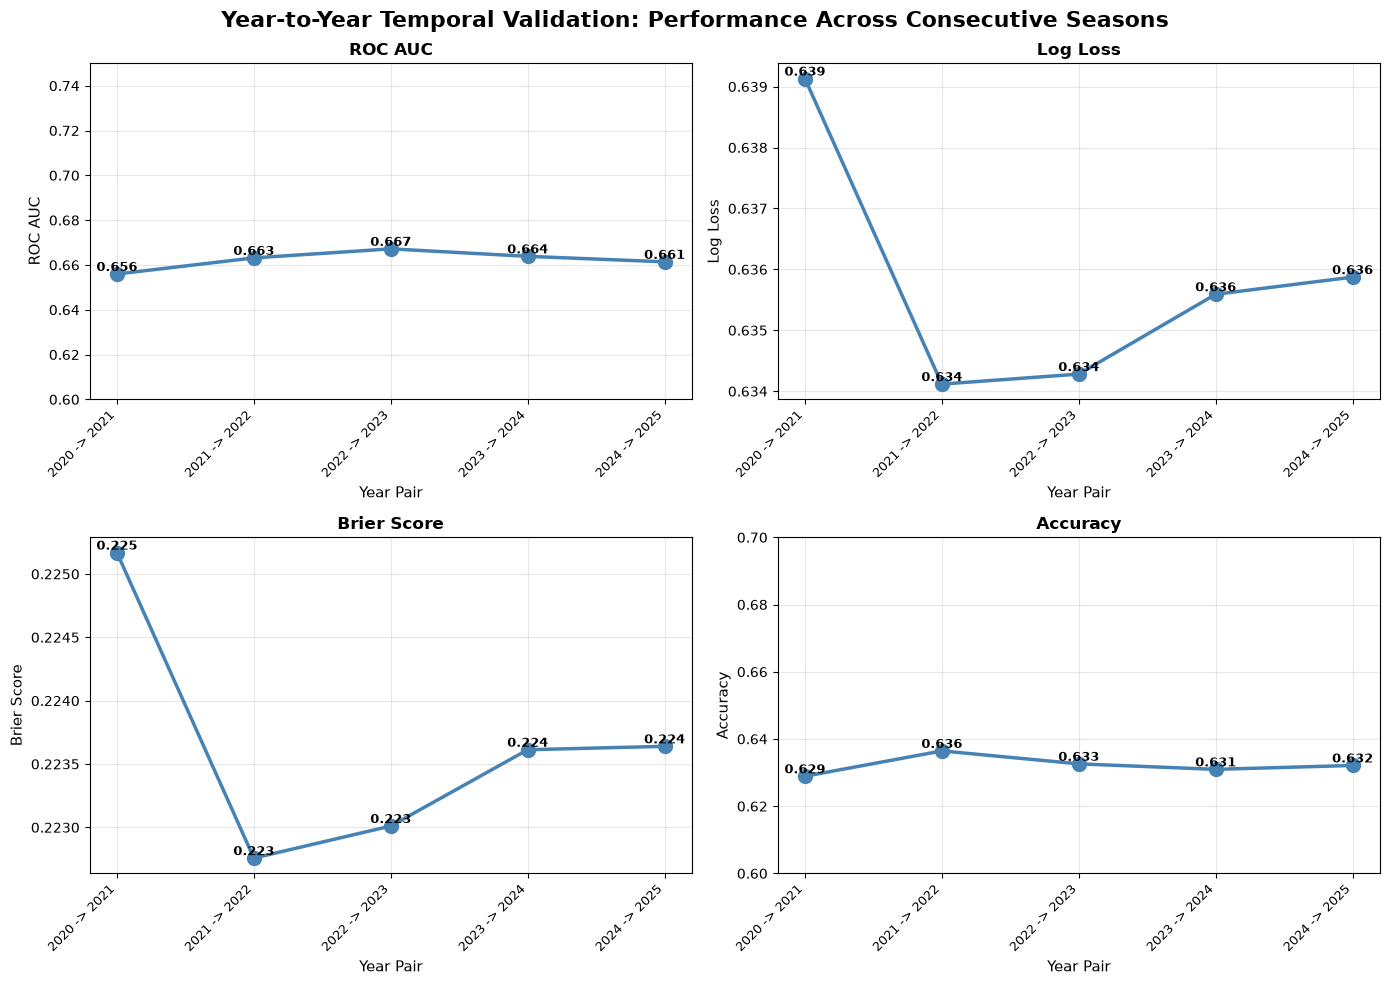

In [6]:
# Plot metrics over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Year-to-Year Temporal Validation: Performance Across Consecutive Seasons', fontsize=16, fontweight='bold')

metrics = [
    ('auc', 'ROC AUC', axes[0, 0], (0.6, 0.75)),
    ('log_loss', 'Log Loss', axes[0, 1], None),
    ('brier', 'Brier Score', axes[1, 0], None),
    ('accuracy', 'Accuracy', axes[1, 1], (0.6, 0.7))
]

for metric_col, metric_name, ax, ylim in metrics:
    ax.plot(range(len(results_df)), results_df[metric_col], 
            marker='o', markersize=10, linewidth=2.5, color='steelblue')
    ax.set_xlabel('Year Pair', fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['fold'], rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3)
    if ylim:
        ax.set_ylim(ylim)
    
    # Add value labels
    for i, val in enumerate(results_df[metric_col]):
        ax.text(i, val, f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Export Results

In [ ]:
# Export detailed results
output_file = 'year_to_year_temporal_validation_results_no_prior_keep_team.csv'
results_df.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")

# Print summary statistics
print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("""
Key Findings:

1. **Year-to-Year Generalization**: Each model trained on only one season
   - Tests if shot quality patterns are stable year-over-year
   - If AUC stays ~0.64-0.68, features generalize well to next season
   - If metrics vary significantly, suggests NBA evolution or rule changes

2. **Comparison with Rolling Validation**:
   - Year-to-year uses 1 season of training (~200k shots)
   - Rolling uses multiple years (~600k-2M shots)
   - Expect slightly lower performance due to less training data

3. **Expected Performance** (with proper leakage prevention):
   - AUC: 0.64-0.68 (realistic shot quality prediction)
   - Accuracy: 62-65%
   - Log Loss: 0.62-0.65

4. **Red Flags** (if you see these, investigate!):
   - AUC > 0.75: Possible data leakage - check features!
   - AUC < 0.60: Features may not capture shot quality
   - Large variance across folds: Unstable model or distribution shift

5. **Why Not Higher?**
   - Shot outcomes have inherent randomness
   - Without defender tracking data, contest estimation is approximate
   - Player skill varies game-to-game (hot/cold streaks)
   - Single-year training has less data than rolling validation
""")
print("="*80)

## Notes

### Data Requirements
This notebook requires enriched shot data for seasons 2019-20 through 2024-25:
- `enriched_data/nbastatsv3_2019_enriched_shots.csv`
- `enriched_data/nbastatsv3_2020_enriched_shots.csv`
- `enriched_data/nbastatsv3_2021_enriched_shots.csv`
- `enriched_data/nbastatsv3_2022_enriched_shots.csv`
- `enriched_data/nbastatsv3_2023_enriched_shots.csv`
- `enriched_data/nbastatsv3_2024_enriched_shots.csv`

And historical stats files:
- `player_historical_stats.csv` (player FG%, 3P%, attempts by season)
- `team_defensive_stats.csv` (opponent FG% allowed by zone and season)

### Model Configuration
- **Algorithm**: LightGBM (best performer from main notebook)
- **Hyperparameters**: Pre-tuned (from Bayesian optimization in main notebook)
- **Features (NO_PRIOR variant)**: 55 total — see actual counts printed by the pipeline
  - Shot clock x location interactions (13 features)
  - Text-parsed shot type features (pullup, stepback, etc.)
  - Court zone features (paint, corner3, above_break3)
  - Opponent defensive stats (opp_def_fg_pct, opp_def_rim_pct, opp_def_3pt_pct, opp_def_mid_pct, opp_def_shot_type_pct)
  - **REMOVED**: prior_fg_pct, prior_fg3_pct, prior_fg2_pct, prior_shot_type_pct, prior_attempts, prior_high_volume, teamTricode (as feature)

### Validation Strategy
- **Year-to-year**: Train on single year, test on next year
- **No cumulative training**: Each fold uses only one training year
- **No overlap**: Test data never appears in training
- **No re-tuning**: Uses fixed hyperparameters for fair comparison
- **Prior stats**: Uses prior year's data (no leakage - e.g., 2019 stats for 2020 shots)

### Expected Runtime
- ~5-10 minutes total (LightGBM is fast)
- Each fold: ~1-2 minutes